## Ячейка 1: Импорты, Фиксация Seed и Создание папок

In [9]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms, models
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.ops import box_iou

# 1. Создаем правильную структуру директорий строго по заданию
base_dir = "homeworks/HW10-11"
artifacts_dir = os.path.join(base_dir, "artifacts")
figures_dir = os.path.join(artifacts_dir, "figures")

os.makedirs(figures_dir, exist_ok=True)
print(f"✅ Папки созданы: {figures_dir}")

# 2. Фиксируем Seed для воспроизводимости
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # torch.backends.cudnn.deterministic = True

set_seed(42)

# 3. Выбираем устройство (GPU или CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Используемое устройство: {device}")

# Создадим пустой список для записи всех результатов экспериментов (он пойдет в runs.csv)
results_log =[]

✅ Папки созданы: homeworks/HW10-11/artifacts/figures
✅ Используемое устройство: cuda


## Ячейка 2: Часть A - Данные (STL10) и Аугментации

Скачиваем датасет STL10... (это займет пару минут)
Данные разделены: Train=4000, Val=1000, Test=8000


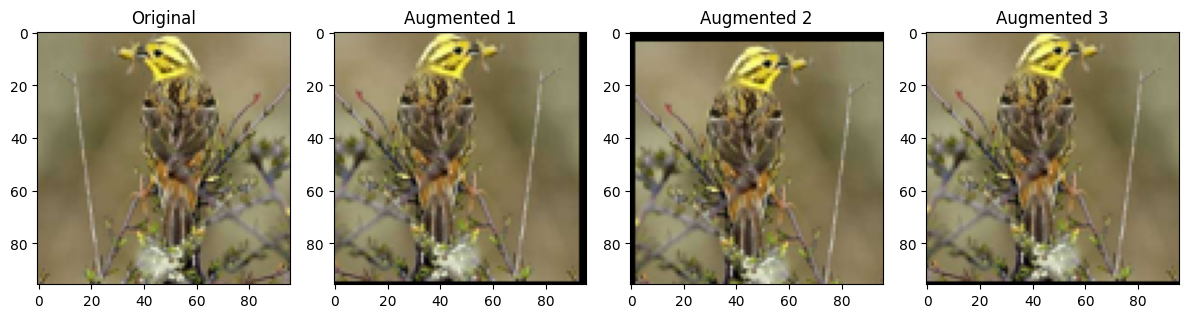

✅ Аугментации визуализированы и сохранены!


In [10]:
# 1. Задаем преобразования (Transforms) для изображений
# Для самописной CNN:
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(96, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Для ResNet18 (нужен размер 224x224 и специфичная нормализация):
resnet_weights = models.ResNet18_Weights.DEFAULT
transform_resnet_base = resnet_weights.transforms() # Базовый трансформ от ImageNet
transform_resnet_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transform_resnet_base
])

# 2. Скачиваем сырые данные (без трансформов, их мы будем применять динамически)
print("Скачиваем датасет STL10... (это займет пару минут)")
raw_train_dataset = datasets.STL10(root='./data', split='train', download=True, transform=None)
raw_test_dataset = datasets.STL10(root='./data', split='test', download=True, transform=None)

# 3. Класс-обертка для применения нужного трансформа к подмножеству
class SubsetWithTransform(torch.utils.data.Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label

# 4. Разбиваем Train (5000) на Train (4000) и Val (1000)
indices = list(range(len(raw_train_dataset)))
np.random.shuffle(indices)
train_idx, val_idx = indices[:4000], indices[4000:]

print(f"Данные разделены: Train={len(train_idx)}, Val={len(val_idx)}, Test={len(raw_test_dataset)}")

# 5. Визуализация аугментаций (Sanity check)
sample_img, _ = raw_train_dataset[0]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(sample_img); axes[0].set_title("Original")

# Применим аугментацию (без ToTensor) для визуализации
vis_aug = transforms.Compose([transforms.RandomHorizontalFlip(p=1.0), transforms.RandomCrop(96, padding=4)])
for i in range(1, 4):
    axes[i].imshow(vis_aug(sample_img))
    axes[i].set_title(f"Augmented {i}")

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "augmentations_preview.png"))
plt.show()
print("✅ Аугментации визуализированы и сохранены!")

## Ячейка 3: Часть A - Архитектуры Моделей и Функции Обучения

In [11]:
# 1. Самописная сверточная сеть (SimpleCNN)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # 96x96 -> 48x48

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)  # 48x48 -> 24x24
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 24 * 24, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# 2. Функция настройки ResNet (Transfer Learning)
def get_resnet_model(mode='head_only', num_classes=10):
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    if mode == 'head_only':
        # Замораживаем ВСЮ сеть
        for param in model.parameters():
            param.requires_grad = False
    elif mode == 'finetune':
        # Замораживаем ранние слои, оставляем обучаться только layer4 и полносвязный слой (fc)
        for name, param in model.named_parameters():
            if not name.startswith('layer4') and not name.startswith('fc'):
                param.requires_grad = False

    # Заменяем "голову" (последний слой) под наши 10 классов (по умолчанию требует градиент)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

# 3. Базовые функции обучения
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += torch.sum(preds == labels.data).item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += torch.sum(preds == labels.data).item()
            total += labels.size(0)

    return running_loss / total, correct / total

## Ячейка 4: Часть A - Выполнение Экспериментов (C1-C4)


🚀 Запуск эксперимента C1: simple-cnn-base
Epoch 1/10 - Loss: 1.844 / 1.713 | Acc: 0.313 / 0.340
Epoch 2/10 - Loss: 1.428 / 1.501 | Acc: 0.480 / 0.460
Epoch 3/10 - Loss: 1.207 / 1.394 | Acc: 0.566 / 0.495
Epoch 4/10 - Loss: 1.021 / 1.390 | Acc: 0.643 / 0.501
Epoch 5/10 - Loss: 0.784 / 1.424 | Acc: 0.726 / 0.512
Epoch 6/10 - Loss: 0.570 / 1.625 | Acc: 0.808 / 0.475
Epoch 7/10 - Loss: 0.372 / 1.595 | Acc: 0.884 / 0.521
Epoch 8/10 - Loss: 0.181 / 1.838 | Acc: 0.957 / 0.527
Epoch 9/10 - Loss: 0.111 / 2.087 | Acc: 0.980 / 0.516
Epoch 10/10 - Loss: 0.071 / 2.440 | Acc: 0.987 / 0.496

🚀 Запуск эксперимента C2: simple-cnn-aug
Epoch 1/10 - Loss: 1.925 / 1.678 | Acc: 0.298 / 0.371
Epoch 2/10 - Loss: 1.547 / 1.552 | Acc: 0.424 / 0.434
Epoch 3/10 - Loss: 1.421 / 1.469 | Acc: 0.476 / 0.454
Epoch 4/10 - Loss: 1.305 / 1.351 | Acc: 0.525 / 0.505
Epoch 5/10 - Loss: 1.219 / 1.311 | Acc: 0.555 / 0.509
Epoch 6/10 - Loss: 1.145 / 1.268 | Acc: 0.586 / 0.540
Epoch 7/10 - Loss: 1.077 / 1.230 | Acc: 0.602 / 0.

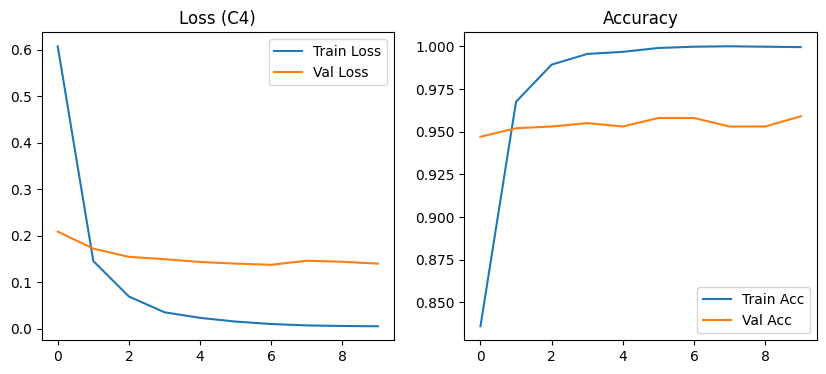

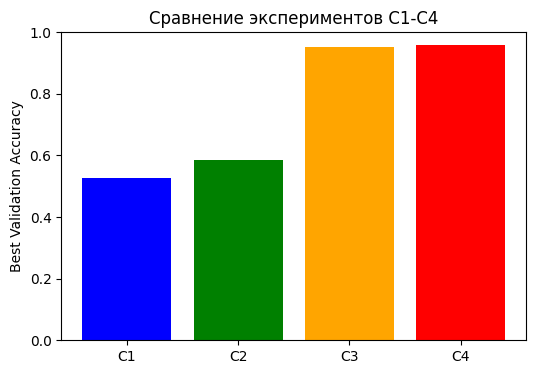

✅ Артефакты Части A сохранены!


In [12]:
EPOCHS = 10
BATCH_SIZE = 64

experiments =[
    {"id": "C1", "name": "simple-cnn-base", "model_fn": lambda: SimpleCNN(), "t_train": transform_base, "t_val": transform_base, "lr": 1e-3},
    {"id": "C2", "name": "simple-cnn-aug",  "model_fn": lambda: SimpleCNN(), "t_train": transform_aug, "t_val": transform_base, "lr": 1e-3},
    {"id": "C3", "name": "resnet-head",     "model_fn": lambda: get_resnet_model('head_only'), "t_train": transform_resnet_aug, "t_val": transform_resnet_base, "lr": 1e-3},
    {"id": "C4", "name": "resnet-finetune", "model_fn": lambda: get_resnet_model('finetune'),  "t_train": transform_resnet_aug, "t_val": transform_resnet_base, "lr": 1e-4}
]

best_overall_acc = 0.0
best_model_state = None
best_model_config = None
best_history = None
histories = {} # Для графика сравнения

for exp in experiments:
    print(f"\n🚀 Запуск эксперимента {exp['id']}: {exp['name']}")

    # Подготавливаем DataLoaders
    train_ds = SubsetWithTransform(raw_train_dataset, train_idx, transform=exp['t_train'])
    val_ds = SubsetWithTransform(raw_train_dataset, val_idx, transform=exp['t_val'])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = exp['model_fn']().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=exp['lr'])

    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'train_acc':[], 'val_acc':[]}

    for epoch in range(EPOCHS):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)
        vl, va = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta); history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            # Сохраняем лучшую модель среди ВСЕХ экспериментов
            if va > best_overall_acc:
                best_overall_acc = va
                best_model_state = model.state_dict().copy()
                best_history = history
                best_model_config = {
                    "exp_id": exp['id'],
                    "model": exp['name'],
                    "dataset": "STL10",
                    "lr": exp['lr'],
                    "epochs": EPOCHS,
                    "seed": 42,
                    "transforms": {
                        "train": str(exp['t_train']),
                        "val": str(exp['t_val'])
                    },
                    "preprocessing": "Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))",
                    "augmentation": "RandomHorizontalFlip(p=0.5), RandomCrop(96, padding=4)"
                }

        print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {tl:.3f} / {vl:.3f} | Acc: {ta:.3f} / {va:.3f}")

    histories[exp['id']] = best_val_acc

    # Сохраняем результат в общий лог
    results_log.append({
        "experiment_id": exp['id'], "task": "classification", "dataset": "STL10", "seed": 42,
        "model_summary": exp['name'], "optimizer": "Adam", "lr": exp['lr'], "epochs_trained": EPOCHS,
        "best_val_accuracy": round(best_val_acc, 4), "test_accuracy": None,
        "precision": None, "recall": None, "mean_iou": None, "notes": f"Best val acc: {best_val_acc:.4f}"
    })

# ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ НА TEST СЕТЕ
print(f"\n🏆 Лучшая модель из {best_model_config['exp_id']} ({best_model_config['model']}) с Val Acc = {best_overall_acc:.4f}")

# Заново создаем лучшую модель
best_model = next(item['model_fn'] for item in experiments if item['id'] == best_model_config['exp_id'])().to(device)
best_model.load_state_dict(best_model_state)

# Трансформ для тестового сета должен быть валидационным от лучшей модели
best_test_transform = next(item['t_val'] for item in experiments if item['id'] == best_model_config['exp_id'])
test_ds = SubsetWithTransform(raw_test_dataset, list(range(len(raw_test_dataset))), transform=best_test_transform)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

_, test_acc = evaluate(best_model, test_loader, nn.CrossEntropyLoss(), device)
print(f"🎯 Итоговая Test Accuracy: {test_acc:.4f}")

# Обновляем Test Acc в логе
for row in results_log:
    if row['experiment_id'] == best_model_config['exp_id']:
        row['test_accuracy'] = round(test_acc, 4)

# СОХРАНЕНИЕ АРТЕФАКТОВ ЧАСТИ А
torch.save(best_model_state, os.path.join(artifacts_dir, "best_classifier.pt"))
with open(os.path.join(artifacts_dir, "best_classifier_config.json"), "w") as f:
    json.dump(best_model_config, f, indent=4)

# ГРАФИКИ
# 1. Кривые лучшего обучения
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(best_history['train_loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Val Loss')
plt.legend(); plt.title(f"Loss ({best_model_config['exp_id']})")
plt.subplot(1, 2, 2)
plt.plot(best_history['train_acc'], label='Train Acc')
plt.plot(best_history['val_acc'], label='Val Acc')
plt.legend(); plt.title("Accuracy")
plt.savefig(os.path.join(figures_dir, "classification_curves_best.png"))
plt.show()

# 2. Сравнение C1-C4
plt.figure(figsize=(6, 4))
plt.bar(histories.keys(), histories.values(), color=['blue', 'green', 'orange', 'red'])
plt.ylabel("Best Validation Accuracy")
plt.title("Сравнение экспериментов C1-C4")
plt.ylim(0, 1.0)
plt.savefig(os.path.join(figures_dir, "classification_compare.png"))
plt.show()
print("✅ Артефакты Части A сохранены!")

## Ячейка 5: Часть B - Детекция объектов (Pascal VOC)

In [13]:
print("Скачиваем Pascal VOC Detection... (Архив 2 ГБ, подождите)")
# Будем использовать только валидационный датасет для оценки
voc_val = datasets.VOCDetection(root='./data', year='2012', image_set='val', download=True)

# Загружаем готовую модель Faster R-CNN
detection_weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
detection_model = fasterrcnn_resnet50_fpn(weights=detection_weights).to(device)
detection_model.eval()
detection_transforms = detection_weights.transforms()

# Функция для конвертации XML аннотаций VOC в тензоры Bounding Boxes [xmin, ymin, xmax, ymax]
def get_gt_boxes(annotation):
    boxes = []
    objects = annotation['annotation'].get('object', [])
    if not isinstance(objects, list):
        objects = [objects]
    for obj in objects:
        bbox = obj['bndbox']
        # Координаты в VOC могут быть строками, переводим во float (VOC индексы с 1, поэтому можно вычесть 1, но для IoU не критично)
        boxes.append([float(bbox['xmin']), float(bbox['ymin']), float(bbox['xmax']), float(bbox['ymax'])])
    return torch.tensor(boxes, dtype=torch.float32)

# Функция для вычисления метрик детекции для одного изображения
def compute_detection_metrics(pred_boxes, gt_boxes, iou_threshold=0.5):
    if len(gt_boxes) == 0 and len(pred_boxes) == 0:
        return 0, 0, 0,[]
    if len(gt_boxes) == 0:
        return 0, len(pred_boxes), 0,[]
    if len(pred_boxes) == 0:
        return 0, 0, len(gt_boxes),[]

    # Считаем матрицу IoU (N предсказаний x M ground truth)
    ious = box_iou(pred_boxes, gt_boxes) # Shape: [N, M]

    tp, fp = 0, 0
    gt_matched = torch.zeros(len(gt_boxes), dtype=torch.bool)
    matched_ious =[]

    # Идем по предсказаниям (они обычно уже отсортированы по score в FasterRCNN)
    for i in range(len(pred_boxes)):
        max_iou, gt_idx = ious[i].max(dim=0)
        if max_iou >= iou_threshold and not gt_matched[gt_idx]:
            tp += 1
            gt_matched[gt_idx] = True
            matched_ious.append(max_iou.item())
        else:
            fp += 1

    fn = len(gt_boxes) - tp
    return tp, fp, fn, matched_ious

Скачиваем Pascal VOC Detection... (Архив 2 ГБ, подождите)


## Ячейка 6: Часть B - Оценка и Визуализация режимов V1 (0.3) и V2 (0.7)

Выполняем инференс на 50 изображениях...
Режим V1 (thr=0.3): Precision=0.279, Recall=0.945, MeanIoU=0.804
Режим V2 (thr=0.7): Precision=0.549, Recall=0.826, MeanIoU=0.817


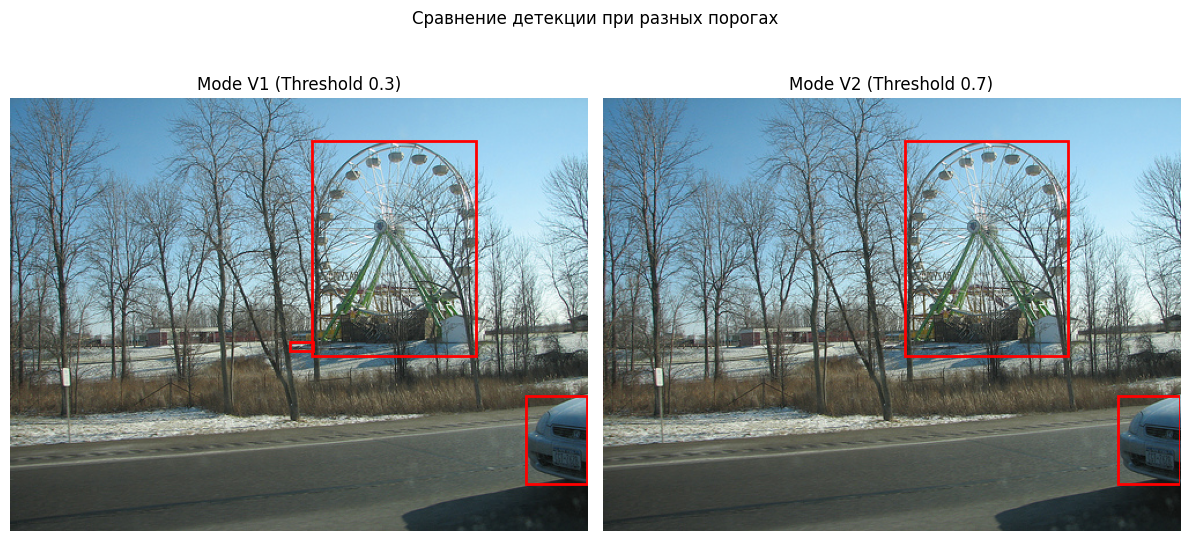

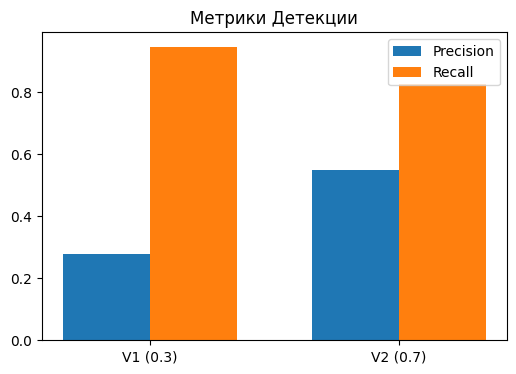

In [14]:
NUM_EVAL_IMAGES = 50 # Берем первые 50 картинок для быстроты
iou_threshold = 0.5

# Режимы (Пороги уверенности)
thresholds = {"V1": 0.3, "V2": 0.7}
metrics_res = { "V1": {"tp":0, "fp":0, "fn":0, "ious":[]}, "V2": {"tp":0, "fp":0, "fn":0, "ious":[]} }

print(f"Выполняем инференс на {NUM_EVAL_IMAGES} изображениях...")
with torch.no_grad():
    for i in range(NUM_EVAL_IMAGES):
        img_pil, target = voc_val[i]
        gt_boxes = get_gt_boxes(target)

        # Подготовка картинки для модели
        img_tensor = detection_transforms(img_pil).unsqueeze(0).to(device)
        predictions = detection_model(img_tensor)[0]

        preds_boxes = predictions['boxes'].cpu()
        preds_scores = predictions['scores'].cpu()

        # Считаем для каждого режима
        for mode, thresh in thresholds.items():
            valid_mask = preds_scores >= thresh
            filtered_boxes = preds_boxes[valid_mask]

            tp, fp, fn, matched_ious = compute_detection_metrics(filtered_boxes, gt_boxes, iou_threshold)
            metrics_res[mode]["tp"] += tp
            metrics_res[mode]["fp"] += fp
            metrics_res[mode]["fn"] += fn
            metrics_res[mode]["ious"].extend(matched_ious)

# Подсчет итоговых метрик и сохранение в CSV
for mode, thresh in thresholds.items():
    tp, fp, fn, ious = metrics_res[mode]["tp"], metrics_res[mode]["fp"], metrics_res[mode]["fn"], metrics_res[mode]["ious"]

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    mean_iou = np.mean(ious) if len(ious) > 0 else 0.0

    print(f"Режим {mode} (thr={thresh}): Precision={precision:.3f}, Recall={recall:.3f}, MeanIoU={mean_iou:.3f}")

    results_log.append({
        "experiment_id": mode, "task": "detection", "dataset": "Pascal VOC", "seed": 42,
        "model_summary": "FasterRCNN_ResNet50_FPN", "optimizer": None, "lr": None, "epochs_trained": None,
        "best_val_accuracy": None, "test_accuracy": None,
        "precision": round(precision, 4), "recall": round(recall, 4), "mean_iou": round(mean_iou, 4),
        "notes": f"Score threshold {thresh}"
    })

# Визуализация предсказаний (на 1 картинке для демонстрации обоих режимов)
sample_img_pil, sample_target = voc_val[10] # Картинка №10
sample_tensor = detection_transforms(sample_img_pil).unsqueeze(0).to(device)
with torch.no_grad():
    sample_preds = detection_model(sample_tensor)[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Сравнение детекции при разных порогах")

for idx, (mode, thresh) in enumerate(thresholds.items()):
    ax = axes[idx]
    ax.imshow(sample_img_pil)
    ax.set_title(f"Mode {mode} (Threshold {thresh})")
    ax.axis('off')

    valid_mask = sample_preds['scores'] >= thresh
    boxes = sample_preds['boxes'][valid_mask].cpu().numpy()

    for box in boxes:
        rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "detection_examples.png"))
plt.show()

# Столбчатая диаграмма метрик детекции
precisions = [results_log[-2]['precision'], results_log[-1]['precision']]
recalls = [results_log[-2]['recall'], results_log[-1]['recall']]

x = np.arange(2)
width = 0.35
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - width/2, precisions, width, label='Precision')
ax.bar(x + width/2, recalls, width, label='Recall')
ax.set_xticks(x); ax.set_xticklabels(['V1 (0.3)', 'V2 (0.7)'])
ax.legend(); ax.set_title("Метрики Детекции")
plt.savefig(os.path.join(figures_dir, "detection_metrics.png"))
plt.show()

## Ячейка 7: Финал и сохранение таблицы результатов

In [15]:
# Сохраняем итоговую таблицу
df_results = pd.DataFrame(results_log)
df_results.to_csv(os.path.join(artifacts_dir, "runs.csv"), index=False)

print("✅ Файл runs.csv успешно сохранен!")
display(df_results)

print(f"\nКОД ВЫПОЛНЕН! Все файлы лежат в папке {base_dir}")
# Если папка homeworks не скачивается целиком (Colab иногда не умеет качать папки), заархивируем её:
import shutil
shutil.make_archive("homeworks_archive", 'zip', "homeworks")
print("Создан архив homeworks_archive.zip — скачай его из панели файлов слева!")

✅ Файл runs.csv успешно сохранен!


,experiment_id,task,dataset,seed,model_summary,optimizer,lr,epochs_trained,best_val_accuracy,test_accuracy,precision,recall,mean_iou,notes
0,C1,classification,STL10,42,simple-cnn-base,Adam,0.0010,10.0,0.527,NaN,NaN,NaN,NaN,Best val acc: 0.5270
1,C2,classification,STL10,42,simple-cnn-aug,Adam,0.0010,10.0,0.585,NaN,NaN,NaN,NaN,Best val acc: 0.5850
2,C3,classification,STL10,42,resnet-head,Adam,0.0010,10.0,0.951,NaN,NaN,NaN,NaN,Best val acc: 0.9510
3,C4,classification,STL10,42,resnet-finetune,Adam,0.0001,10.0,0.959,0.9524,NaN,NaN,NaN,Best val acc: 0.9590
4,V1,detection,Pascal VOC,42,FasterRCNN_ResNet50_FPN,None,NaN,NaN,NaN,NaN,0.2791,0.9450,0.804,Score threshold 0.3
5,V2,detection,Pascal VOC,42,FasterRCNN_ResNet50_FPN,None,NaN,NaN,NaN,NaN,0.5488,0.8257,0.817,Score threshold 0.7



КОД ВЫПОЛНЕН! Все файлы лежат в папке homeworks/HW10-11
Создан архив homeworks_archive.zip — скачай его из панели файлов слева!
